In [7]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from sklearn.linear_model import LinearRegression

In [8]:
df=pd.read_csv("enhanced_house_price_dataset.csv")    # loading dataset 

In [10]:
#checking dataset
df.head()

,Area,Bedrooms,Bathrooms,Stories,Parking,Age,City,Furnishing,Main Road,Guest Room,Basement,Water Supply,Air Conditioning,Preferred Tenant,Locality Rating,Price
0,1260,4,3,2,1,24,Pune,Semi-Furnished,Yes,Yes,Yes,Both,No,Company,4,1274350
1,5790,2,1,1,1,7,Kolkata,Unfurnished,Yes,Yes,Yes,Both,Yes,Bachelor,5,1094846
2,5626,5,2,3,0,15,Chennai,Semi-Furnished,No,Yes,Yes,Corporation,Yes,Company,6,1495933
3,5591,1,1,1,1,47,Delhi,Furnished,Yes,No,Yes,Borewell,No,Company,3,1003442
4,4172,5,1,1,1,44,Delhi,Unfurnished,No,No,No,Borewell,Yes,Bachelor,1,1306676


In [11]:
df.tail()

,Area,Bedrooms,Bathrooms,Stories,Parking,Age,City,Furnishing,Main Road,Guest Room,Basement,Water Supply,Air Conditioning,Preferred Tenant,Locality Rating,Price
1995,4323,1,1,2,0,23,Kolkata,Unfurnished,Yes,Yes,No,Borewell,Yes,Company,6,768553
1996,4803,4,2,1,1,8,Kolkata,Furnished,No,No,Yes,Both,No,Company,2,1117994
1997,5855,5,2,3,0,6,Kolkata,Furnished,No,Yes,No,Borewell,No,Bachelor,4,1800277
1998,2369,3,3,2,2,15,Chennai,Furnished,Yes,No,Yes,Both,Yes,Family,7,1547695
1999,3193,5,2,1,0,18,Pune,Unfurnished,Yes,Yes,No,Corporation,Yes,Bachelor,1,1286827


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Area              2000 non-null   int64 
 1   Bedrooms          2000 non-null   int64 
 2   Bathrooms         2000 non-null   int64 
 3   Stories           2000 non-null   int64 
 4   Parking           2000 non-null   int64 
 5   Age               2000 non-null   int64 
 6   City              2000 non-null   object
 7   Furnishing        2000 non-null   object
 8   Main Road         2000 non-null   object
 9   Guest Room        2000 non-null   object
 10  Basement          2000 non-null   object
 11  Water Supply      2000 non-null   object
 12  Air Conditioning  2000 non-null   object
 13  Preferred Tenant  2000 non-null   object
 14  Locality Rating   2000 non-null   int64 
 15  Price             2000 non-null   int64 
dtypes: int64(8), object(8)
memory usage: 250.1+ KB


In [14]:
df.shape

(2000, 16)

In [15]:
df.describe()

,Area,Bedrooms,Bathrooms,Stories,Parking,Age,Locality Rating,Price
count,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000,2000.000000,2.000000e+03
mean,3238.081000,3.031000,2.02150,1.996000,0.990500,24.008500,5.357500,1.245014e+06
std,1604.510239,1.427255,0.81263,0.811981,0.806682,14.319076,2.843015,3.001744e+05
min,401.000000,1.000000,1.00000,1.000000,0.000000,0.000000,1.000000,3.346350e+05
25%,1860.000000,2.000000,1.00000,1.000000,0.000000,12.000000,3.000000,1.035278e+06
50%,3271.500000,3.000000,2.00000,2.000000,1.000000,24.000000,5.000000,1.246602e+06
75%,4599.750000,4.000000,3.00000,3.000000,2.000000,36.000000,8.000000,1.453607e+06
max,5996.000000,5.000000,3.00000,3.000000,2.000000,49.000000,10.000000,2.225409e+06


In [17]:
#Target 
df.columns

Index(['Area', 'Bedrooms', 'Bathrooms', 'Stories', 'Parking', 'Age', 'City',
       'Furnishing', 'Main Road', 'Guest Room', 'Basement', 'Water Supply',
       'Air Conditioning', 'Preferred Tenant', 'Locality Rating', 'Price'],
      dtype='object')

In [20]:
df["Price"]

0       1274350
1       1094846
2       1495933
3       1003442
4       1306676
         ...   
1995     768553
1996    1117994
1997    1800277
1998    1547695
1999    1286827
Name: Price, Length: 2000, dtype: int64

In [22]:
#cleaning data 
df.isnull().sum()

Area                0
Bedrooms            0
Bathrooms           0
Stories             0
Parking             0
Age                 0
City                0
Furnishing          0
Main Road           0
Guest Room          0
Basement            0
Water Supply        0
Air Conditioning    0
Preferred Tenant    0
Locality Rating     0
Price               0
dtype: int64

In [24]:
df.fillna(df.mean(numeric_only=True),inplace=True) # handling missing values 

In [40]:
df[col] = df[col].fillna(df[col].mode()[0])

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [36]:
# features 
X=df.drop("Price",axis=1)
y=df["Price"]

In [37]:
#Train test split
X_train,X_test,y_train,y_test=train_test_split(
X,y,test_size=0.2,random_state=42)

In [38]:
# training the model
model=LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [41]:
y_pred=model.predict(X_test)

In [47]:
#evaluation the model
mae = mean_absolute_error(y_test,y_pred)
print("MAE:",mae)

MAE: 111582.41556484067


In [48]:
rmse = np.sqrt(mean_squared_error(y_test,y_pred))
print("RMSE:",rmse)

RMSE: 141465.76360213282


In [49]:
r2 = r2_score(y_test,y_pred)
print("R2:",r2)       # good model

R2: 0.7792130781487584


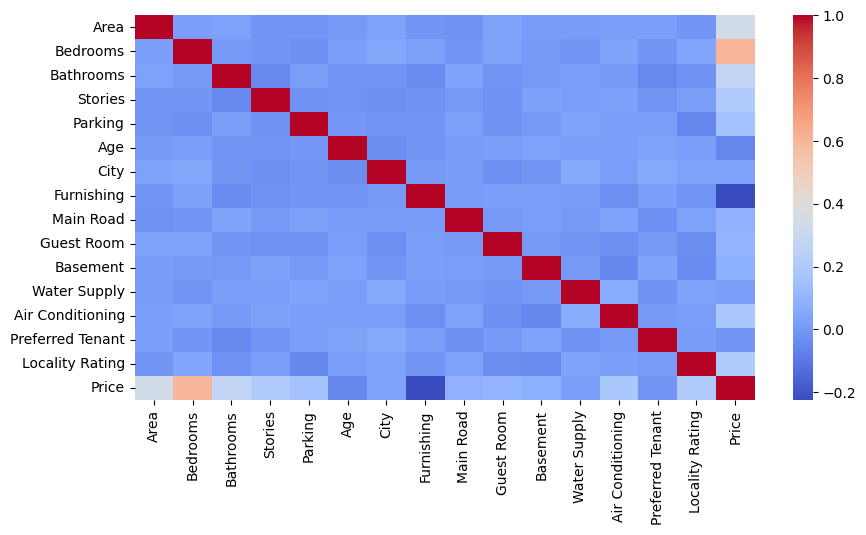

In [59]:
# visualization
plt.figure(figsize=(10,5))
sns.heatmap(df.corr() ,cmap='coolwarm')
plt.show()

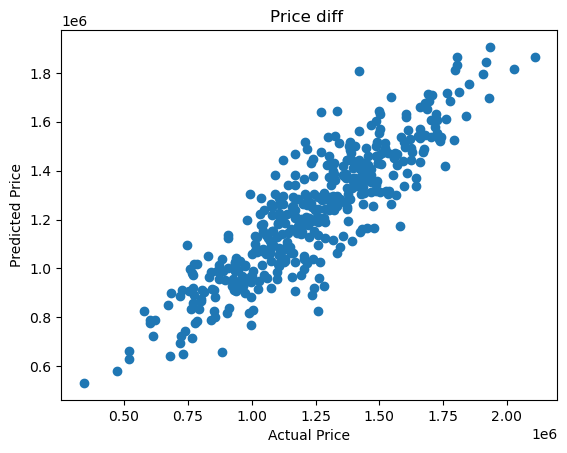

In [56]:
plt.scatter(y_test,y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Price diff ")
plt.show()

In [63]:
# random forect is better model
from sklearn.ensemble import RandomForestRegressor


In [64]:
model=RandomForestRegressor()

In [65]:
model.fit(X_train, y_train)

RandomForestRegressor()

In [66]:
y_pred=model.predict(X_test)

In [67]:
mae = mean_absolute_error(y_test,y_pred)
print("MAE:",mae)

MAE: 134131.630275


In [68]:
rmse = np.sqrt(mean_squared_error(y_test,y_pred))
print("RMSE:",rmse)

RMSE: 168038.92420783208


In [69]:
r2 = r2_score(y_test,y_pred)
print("R2:",r2)       # good model


R2: 0.6884767726650859


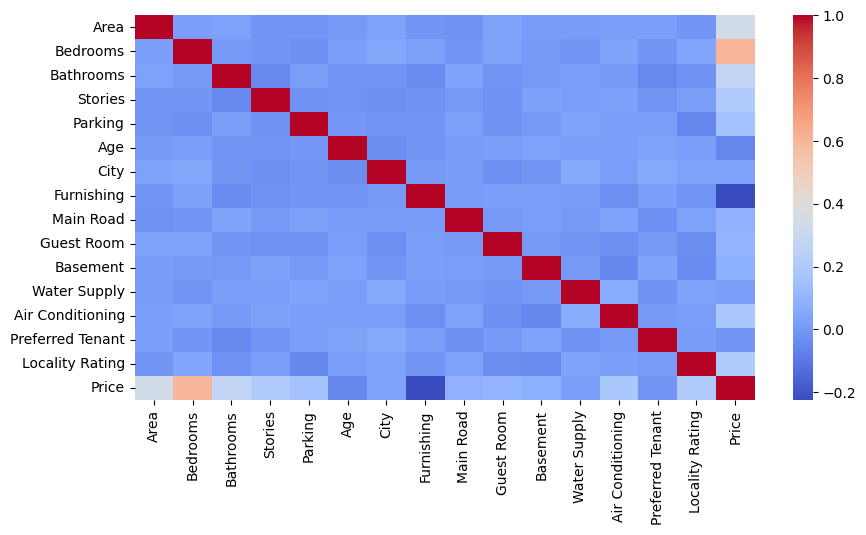

In [70]:
plt.figure(figsize=(10,5))
sns.heatmap(df.corr() ,cmap='coolwarm')
plt.show()

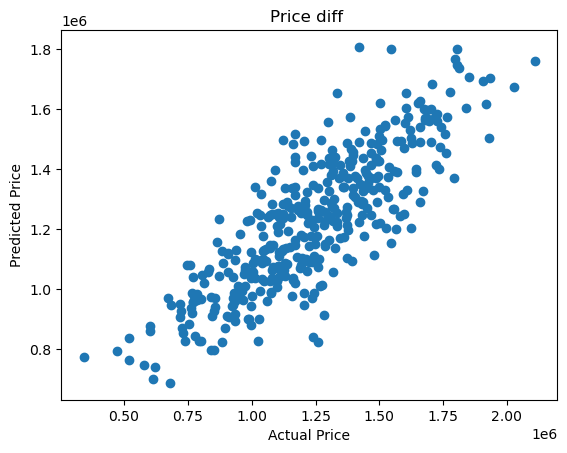

In [71]:
plt.scatter(y_test,y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Price diff ")
plt.show()

In [ ]:
# conclusion 
Random Forest performed better than Linear Regression
with higher R² score and lower RMSE.